# Group 2, Notebook_A (Student A): data, EDA, cleaning, SQL, RQ1 figures

**Topic:** Short-term aftershock forecasting for the Japan-Kuril region, using two U.S. government data sources.

| | Source 1 | Source 2 |
|---|---|---|
| Agency | **USGS** (U.S. Geological Survey, Department of the Interior) | **NOAA/NCEI** (Department of Commerce) |
| Dataset | ANSS ComCat, via the FDSN Event Web Service | Global Significant Earthquake DB + Global Historical Tsunami DB |
| Original link | `earthquake.usgs.gov/fdsnws/event/1/` | `ngdc.noaa.gov/hazel/hazard-service/api/v1/` |
| Content | seismic parameters of each event | consequences: deaths, damage, tsunamis, runup |

Both are downloaded directly from the federal agency sites, not through Kaggle or a re-published copy.

**Notebook_A covers Steps 0 to 3 and the RQ1 figures.** Handoff to Notebook_B: `data/processed/mainshocks.parquet` + `data/processed/manifest.json`.

## Asking AI as you go and keeping an Audit Log: a light, tidy workflow

Every time you ask an AI and the answer **changes the work**, add one line to `docs/AI_Audit_Log_A.md`:

| Date | Prompt asked | What the AI answered | Kept / edited / dropped | Why |
|---|---|---|---|---|

Three rules:
1. **Never paste numbers from the AI into the work.** Every number in the report must come out of this notebook.
2. **Ask "why", not "write it for me".** A good example: *"why do we have to decluster before splitting train/test?"*
3. **Anything the AI said that you have not verified must be marked as unverified**, not written as confirmed.

## Step 0: environment and folder structure

Run the cell below once. If a library is missing, install it and run again.

```
Project/
  data/raw_japan/        <- CSVs downloaded from USGS + NOAA (scripts/fetch_japan_quake_data.py)
  data/processed/        <- mainshocks.parquet + manifest.json (created by Notebook_A)
  report/                <- table_*.csv and fig_*.png
  sql/queries.sql        <- written by Notebook_A when it runs
```

In [1]:
# Step 0: check the environment and create the folder structure
import sys, json, hashlib, warnings, pathlib
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd, duckdb
import matplotlib, matplotlib.pyplot as plt
from scipy import stats

print("python  ", sys.version.split()[0])
for m in (np, pd, duckdb, matplotlib):
    print(f"{m.__name__:<12}", m.__version__)

ROOT = pathlib.Path(".")
RAW  = ROOT / "data" / "raw_japan"
PROC = ROOT / "data" / "processed"
REP  = ROOT / "report"
SQLD = ROOT / "sql"
for d in (PROC, REP, SQLD):
    d.mkdir(parents=True, exist_ok=True)

need = ["usgs_japan_1990_2026.csv", "ncei_earthquakes.csv",
        "ncei_tsunami_events.csv", "ncei_tsunami_runups.csv"]
missing = [f for f in need if not (RAW / f).exists()]
assert not missing, f"Missing files in {RAW}: {missing}\n-> run: python scripts/fetch_japan_quake_data.py"
print("\nAll data present:")
for f in need:
    print(f"  {f:<34} {(RAW/f).stat().st_size/1e6:>7.2f} MB")

python   3.12.10
numpy        2.5.3
pandas       3.0.6
duckdb       1.5.5
matplotlib   3.11.2

All data present:
  usgs_japan_1990_2026.csv              7.27 MB
  ncei_earthquakes.csv                  0.06 MB
  ncei_tsunami_events.csv               0.05 MB
  ncei_tsunami_runups.csv               2.35 MB


In [2]:
# Standard color palette for every figure (CVD-validated: see docs)
PAL = {"s1": "#2a78d6", "s2": "#eb6834", "s3": "#1baf7a",
       "ink": "#0b0b0b", "ink2": "#52514e", "muted": "#898781",
       "grid": "#e1e0d9", "axis": "#c3c2b7", "surface": "#fcfcfb"}
SEQ5 = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281"]   # single-hue ramp, light -> dark

plt.rcParams.update({
    "figure.facecolor": PAL["surface"], "axes.facecolor": PAL["surface"],
    "savefig.facecolor": PAL["surface"], "figure.dpi": 110, "savefig.dpi": 150,
    "savefig.bbox": "tight", "font.size": 10.5,
    "axes.edgecolor": PAL["axis"], "axes.labelcolor": PAL["ink2"],
    "axes.titlecolor": PAL["ink"], "axes.titleweight": "semibold",
    "axes.titlelocation": "left", "axes.titlepad": 11,
    "axes.grid": True, "grid.color": PAL["grid"], "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": PAL["muted"], "ytick.color": PAL["muted"],
    "xtick.labelcolor": PAL["ink2"], "ytick.labelcolor": PAL["ink2"],
    "lines.linewidth": 2.0, "lines.markersize": 8,
    "legend.frameon": False,
})

def finish(ax, title, sub=None, xlab=None, ylab=None):
    "Place title + subtitle WITHOUT overlap, label axes, push the grid behind marks."
    ax.set_title("")
    if sub:
        ax.text(0, 1.012, sub, transform=ax.transAxes, fontsize=9.5,
                color=PAL["muted"], va="bottom")
        ax.text(0, 1.088, title, transform=ax.transAxes, fontsize=12.5,
                color=PAL["ink"], fontweight="semibold", va="bottom")
    else:
        ax.text(0, 1.012, title, transform=ax.transAxes, fontsize=12.5,
                color=PAL["ink"], fontweight="semibold", va="bottom")
    if xlab: ax.set_xlabel(xlab)
    if ylab: ax.set_ylabel(ylab)
    ax.set_axisbelow(True)
    return ax

def save(fig, name):
    p = REP / name
    fig.savefig(p)
    print("saved figure:", p)

print("palette and shared style loaded")

palette and shared style loaded


## Step 1: understand the problem and load the data

### 1.1. The problem and four research questions

When an earthquake has just happened, the first practical question is: **will there be more aftershocks soon?** This is a real forecasting problem; seismic agencies publish exactly this product.

Problem definition in this project:

- **Unit of analysis:** one **sequence**, i.e. one mainshock after declustering.
- **Label:** within **24 hours** after the mainshock, within a **100 km** radius, is there at least one aftershock `M ≥ Mc` or not.
- **Features:** only information **known at the time of the mainshock**: magnitude, depth, location. Nothing from the future.

Four research questions:

| RQ | Question | Notebook |
|---|---|---|
| **RQ1** | How are Japan-Kuril earthquakes from 1990 to 2026 distributed in space, depth, time and magnitude? Is depth related to aftershock productivity? | **A** |
| **RQ2** | From mainshock parameters, can a forecast of aftershocks within 24h beat a naive baseline and a physics baseline? | B |
| **RQ3** | Does the model generalize to an unseen period? Does it hold when the label threshold moves to a damaging level? | C |
| **RQ4** | Which sequences lead to real consequences (deaths, damage, tsunamis)? Join the NOAA/NCEI source. | D |

**The label boundary is a time boundary.** Features sit at time `t`, the label sits in `(t, t+24h]`. So the label cannot overlap with the features. This is the key difference from projects where the label is derived from an input column.

In [3]:
# Step 1: load both sources
usgs = pd.read_csv(RAW / "usgs_japan_1990_2026.csv", low_memory=False)
usgs["time"] = pd.to_datetime(usgs["time"], utc=True, errors="coerce", format="ISO8601")

ncei_eq   = pd.read_csv(RAW / "ncei_earthquakes.csv", low_memory=False)
ncei_tsu  = pd.read_csv(RAW / "ncei_tsunami_events.csv", low_memory=False)
ncei_run  = pd.read_csv(RAW / "ncei_tsunami_runups.csv", low_memory=False)

print("SOURCE 1 - USGS ANSS ComCat")
print(f"  {len(usgs):>7,} rows x {usgs.shape[1]} columns")
print(f"  time      : {usgs['time'].min():%Y-%m-%d} -> {usgs['time'].max():%Y-%m-%d}")
print(f"  magnitude : M{usgs['mag'].min():.1f} -> M{usgs['mag'].max():.1f}")
print(f"  depth     : {usgs['depth'].min():.1f} -> {usgs['depth'].max():.1f} km")
print("\nSOURCE 2 - NOAA/NCEI")
for nm, d in [("significant earthquakes", ncei_eq), ("tsunami events", ncei_tsu),
              ("tsunami runups", ncei_run)]:
    print(f"  {nm:<24} {len(d):>7,} rows x {d.shape[1]} columns")

print("\nBounding box used for the download (state it in the report):")
print("  latitude  24N - 46N,  longitude 122E - 150E")
print("  -> this box covers Japan AND the southern Kuril Islands (Russia).")
print("     So the work calls it the 'Japan-Kuril region', not 'Japan', to be accurate.")

SOURCE 1 - USGS ANSS ComCat
   40,931 rows x 22 columns
  time      : 1990-01-01 -> 2026-09-25
  magnitude : M4.0 -> M9.1
  depth     : 0.0 -> 686.4 km

SOURCE 2 - NOAA/NCEI
  significant earthquakes      429 rows x 46 columns
  tsunami events               385 rows x 48 columns
  tsunami runups            12,939 rows x 52 columns

Bounding box used for the download (state it in the report):
  latitude  24N - 46N,  longitude 122E - 150E
  -> this box covers Japan AND the southern Kuril Islands (Russia).
     So the work calls it the 'Japan-Kuril region', not 'Japan', to be accurate.


### 1.2. EDA part 1: table structure and what each column means

The USGS table has 22 columns. What to know before using them: **not every column is usable**. Some columns have almost a single value (no information), some are more than half missing, and some **encode which agency processed the record**. That last kind is dangerous because it correlates with the time period, so a model would learn "which era is this record from" instead of learning seismology.

In [4]:
# EDA 1: structure and meaning of the columns
MEANING = {
 "time":"origin time (UTC)", "latitude":"epicenter latitude","longitude":"epicenter longitude",
 "depth":"hypocenter depth (km)","mag":"magnitude","magType":"magnitude scale type (mww, mb, ...)",
 "nst":"number of stations used for location","gap":"largest azimuthal gap (degrees)",
 "dmin":"distance to nearest station","rms":"root-mean-square phase residual",
 "net":"network that contributed the record","id":"event id","updated":"last update time",
 "place":"location description","type":"event type","horizontalError":"horizontal error (km)",
 "depthError":"depth error (km)","magError":"magnitude error","magNst":"number of stations for magnitude",
 "status":"reviewed or automatic","locationSource":"agency that located the event","magSource":"agency that computed the magnitude",
}
info = pd.DataFrame({
    "meaning": [MEANING.get(c, "") for c in usgs.columns],
    "dtype":   [str(usgs[c].dtype) for c in usgs.columns],
    "n_unique": [usgs[c].nunique(dropna=True) for c in usgs.columns],
    "pct_missing": [round(usgs[c].isna().mean()*100, 2) for c in usgs.columns],
}, index=usgs.columns)
display(info)

print("\nSummary of the main numeric columns:")
display(usgs[["mag","depth","latitude","longitude","rms"]].describe().round(3))

,meaning,dtype,n_unique,pct_missing
time,origin time (UTC),"datetime64[us, UTC]",40931,0.00
latitude,epicenter latitude,float64,27758,0.00
longitude,epicenter longitude,float64,25504,0.00
depth,hypocenter depth (km),float64,11152,0.00
mag,magnitude,float64,45,0.00
magType,"magnitude scale type (mww, mb, ...)",str,9,0.00
nst,number of stations used for location,float64,590,42.09
gap,largest azimuthal gap (degrees),float64,2085,24.25
dmin,distance to nearest station,float64,4456,61.93
rms,root-mean-square phase residual,float64,174,1.05



Summary of the main numeric columns:


,mag,depth,latitude,longitude,rms
count,40931.000,40931.000,40931.000,40931.000,40502.000
mean,4.548,66.786,34.936,139.582,0.857
std,0.414,98.657,5.996,6.400,0.249
min,4.000,0.000,24.000,122.000,0.100
25%,4.300,17.800,29.686,138.808,0.690
50%,4.500,35.000,36.007,141.650,0.840
75%,4.700,59.630,39.384,143.128,1.010
max,9.100,686.390,45.999,149.999,1.940


### 1.3. EDA part 2: column audit, which columns to drop and why

Drop rules, decided **before** looking at how any model performs (so columns are not chosen by their results):

1. **≥ 99% a single value**: drop, it carries no information.
2. **≥ 50% missing**: drop as a feature, use only for description.
3. **Encodes the agency / measurement quality** (`net`, `locationSource`, `magSource`, `*Error`, `nst`, `gap`, `magNst`, `status`): **drop even when complete**. Reason: network quality improves decade by decade, so these columns are a **time fingerprint**. When train/test is split by time, a model could use them to guess "which era is this data from". That is learning the measurement process, not the seismology.

In [5]:
# EDA 2: column audit -> report/table_col_audit.csv
FINGERPRINT = {"net","locationSource","magSource","horizontalError","depthError",
               "magError","nst","gap","magNst","status","dmin","rms","updated","id","place","type"}
rows = []
for c in usgs.columns:
    nn = usgs[c].notna().sum()
    dom = usgs[c].value_counts(dropna=True).iloc[0] / nn * 100 if nn else 0.0
    miss = usgs[c].isna().mean() * 100
    reasons = []
    if nn == 0:                 reasons.append("completely empty")
    if dom >= 99:               reasons.append(f"{dom:.1f}% a single value")
    if miss >= 50:              reasons.append(f"{miss:.0f}% missing")
    if c in FINGERPRINT:        reasons.append("agency/era fingerprint")
    rows.append({"column": c, "pct_most_common": round(dom,2), "pct_missing": round(miss,2),
                 "decision": "DROP" if reasons else "KEEP",
                 "reason": "; ".join(reasons) if reasons else "usable as a feature or label"})
audit = pd.DataFrame(rows)
audit.to_csv(REP / "table_col_audit.csv", index=False)
display(audit)

KEEP = audit.loc[audit["decision"] == "KEEP", "column"].tolist()
print("\nColumns kept:", KEEP)
print(f"-> kept {len(KEEP)}/{len(usgs.columns)} columns. Model features will only come from these.")

,column,pct_most_common,pct_missing,decision,reason
0,time,0.00,0.00,KEEP,usable as a feature or label
1,latitude,0.02,0.00,KEEP,usable as a feature or label
2,longitude,0.03,0.00,KEEP,usable as a feature or label
3,depth,18.38,0.00,KEEP,usable as a feature or label
4,mag,13.11,0.00,KEEP,usable as a feature or label
5,magType,84.80,0.00,KEEP,usable as a feature or label
6,nst,2.14,42.09,DROP,agency/era fingerprint
7,gap,1.75,24.25,DROP,agency/era fingerprint
8,dmin,0.10,61.93,DROP,62% missing; agency/era fingerprint
9,rms,3.65,1.05,DROP,agency/era fingerprint



Columns kept: ['time', 'latitude', 'longitude', 'depth', 'mag', 'magType']
-> kept 6/22 columns. Model features will only come from these.


## Step 2: cleaning, choosing the completeness threshold Mc, declustering

Three tasks, in order, each with its own reason:

**2a. Cleaning.** Drop rows missing coordinates / time / magnitude, drop duplicate ids, sort by time.

**2b. Choosing Mc (magnitude of completeness).** The catalog is incomplete at small magnitudes: the network does not record every small event. Left as is, "no aftershock" would be mixed up with "there was one but nobody recorded it". We estimate Mc with **maximum curvature + 0.2** (Woessner & Wiemer 2005) and use only the part of the catalog at or above Mc.

**2c. Declustering with Gardner-Knopoff 1974.** Aftershocks are not independent of their mainshock. If they stay in and train/test is split at random, aftershocks of the same sequence land on both sides, which is leakage. Gardner-Knopoff defines a space-time window around each event based on its magnitude:

$$d(M) = 10^{\,0.1238M + 0.983}\ \text{km}, \qquad
t(M) = \begin{cases} 10^{\,0.032M + 2.7389} & M \ge 6.5 \\ 10^{\,0.5409M - 0.547} & M < 6.5 \end{cases}\ \text{days}$$

Every smaller event inside the window of a larger event is assigned as an aftershock of that sequence.

In [6]:
# Step 2a: cleaning + cleaning log
log = []
def step(name, before, after, note=""):
    log.append({"step": name, "rows_before": before, "rows_after": after,
                "removed": before - after, "note": note})

h = usgs.copy(); n0 = len(h)
h = h.dropna(subset=["time"]);                      step("drop missing time", n0, len(h)); n0 = len(h)
h = h.dropna(subset=["latitude","longitude"]);      step("drop missing coordinates", n0, len(h)); n0 = len(h)
h = h.dropna(subset=["mag"]);                       step("drop missing magnitude", n0, len(h)); n0 = len(h)
h = h.dropna(subset=["depth"]);                     step("drop missing depth", n0, len(h)); n0 = len(h)
h = h.drop_duplicates(subset="id");                 step("drop duplicate ids", n0, len(h)); n0 = len(h)
h = h[h["type"] == "earthquake"];                   step("keep only type=earthquake", n0, len(h),
                                                         "drops mine blasts, landslides...")
h = h.sort_values("time").reset_index(drop=True)

clean_log = pd.DataFrame(log)
clean_log.to_csv(REP / "table_cleaning_log.csv", index=False)
display(clean_log)
print(f"{len(h):,} clean events remain.")

,step,rows_before,rows_after,removed,note
0,drop missing time,40931,40931,0,
1,drop missing coordinates,40931,40931,0,
2,drop missing magnitude,40931,40931,0,
3,drop missing depth,40931,40931,0,
4,drop duplicate ids,40931,40931,0,
5,keep only type=earthquake,40931,40924,7,"drops mine blasts, landslides..."


40,924 clean events remain.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


mode of the magnitude histogram : M 4.4
Mc = maximum curvature + 0.2    : M 4.6
b-value (Gutenberg-Richter, fitted from Mc) = 1.02   (typical values ~0.8-1.2)


saved figure: report\fig_rq1_gutenberg_richter.png


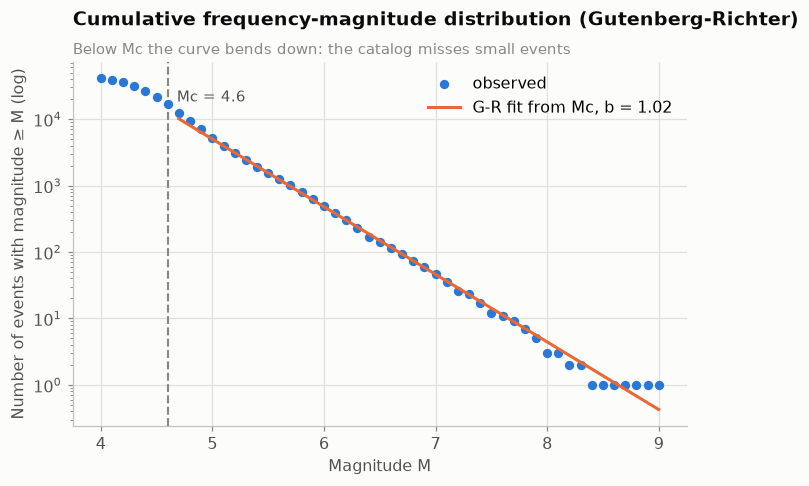


Catalog used from here on: 16,687 events (M >= 4.6)


In [7]:
# Step 2b: estimate Mc with maximum curvature + 0.2
bins = np.arange(np.floor(h["mag"].min()*10)/10, h["mag"].max()+0.1, 0.1)
cnt, edges = np.histogram(h["mag"], bins=bins)
mc_maxc = edges[int(np.argmax(cnt))]
Mc = round(float(mc_maxc) + 0.2, 1)
print(f"mode of the magnitude histogram : M {mc_maxc:.1f}")
print(f"Mc = maximum curvature + 0.2    : M {Mc:.1f}")

# Gutenberg-Richter: check that the cumulative curve is straight from Mc upward
mags = np.arange(4.0, h["mag"].max(), 0.1)
Ncum = np.array([(h["mag"] >= m).sum() for m in mags])
ok = (mags >= Mc) & (Ncum > 0)
b_gr, a_gr = np.polyfit(mags[ok], np.log10(Ncum[ok]), 1)
print(f"b-value (Gutenberg-Richter, fitted from Mc) = {-b_gr:.2f}   (typical values ~0.8-1.2)")

fig, ax = plt.subplots(figsize=(7.2, 4.3))
ax.scatter(mags, Ncum, s=26, color=PAL["s1"], zorder=3, label="observed")
ax.plot(mags[ok], 10**(a_gr + b_gr*mags[ok]), color=PAL["s2"], lw=2,
        label=f"G-R fit from Mc, b = {-b_gr:.2f}", zorder=4)
ax.axvline(Mc, color=PAL["muted"], ls="--", lw=1.4, zorder=2)
ax.annotate(f"Mc = {Mc}", xy=(Mc, Ncum.max()*0.45), xytext=(6, 0),
            textcoords="offset points", color=PAL["ink2"], fontsize=10)
ax.set_yscale("log")
finish(ax, "Cumulative frequency-magnitude distribution (Gutenberg-Richter)",
       "Below Mc the curve bends down: the catalog misses small events",
       "Magnitude M", "Number of events with magnitude ≥ M (log)")
ax.legend(loc="upper right")
save(fig, "fig_rq1_gutenberg_richter.png"); plt.show()

cat = h[h["mag"] >= Mc].reset_index(drop=True)
print(f"\nCatalog used from here on: {len(cat):,} events (M >= {Mc})")

In [8]:
# Step 2c: Gardner-Knopoff 1974 declustering
R_EARTH = 6371.0
def haversine_km(lat1, lon1, lat2, lon2):
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = p2 - p1
    dlam = np.radians(lon2 - lon1)
    x = np.sin(dphi/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dlam/2)**2
    return 2 * R_EARTH * np.arcsin(np.sqrt(np.clip(x, 0, 1)))

def gk_window(m):
    "Gardner-Knopoff 1974: returns (radius km, time days)."
    d = 10 ** (0.1238*m + 0.983)
    t = np.where(m >= 6.5, 10**(0.032*m + 2.7389), 10**(0.5409*m - 0.547))
    return d, t

t_s  = cat["time"].values.astype("datetime64[s]").astype(np.int64)
lat_, lon_, mag_ = cat["latitude"].values, cat["longitude"].values, cat["mag"].values
n = len(cat)
cluster_id = np.full(n, -1, dtype=np.int64)     # -1 = independent (mainshock)
cid = 0
for i in np.argsort(-mag_):                      # go from the largest event down
    if cluster_id[i] != -1:
        continue
    d_km, t_day = gk_window(mag_[i])
    lo = np.searchsorted(t_s, t_s[i])
    hi = np.searchsorted(t_s, t_s[i] + int(t_day * 86400))
    if hi <= lo + 1:
        continue
    idx = np.arange(lo, hi)
    idx = idx[(cluster_id[idx] == -1) & (mag_[idx] < mag_[i]) & (idx != i)]
    if idx.size == 0:
        continue
    hit = idx[haversine_km(lat_[i], lon_[i], lat_[idx], lon_[idx]) <= d_km]
    if hit.size:
        cluster_id[hit] = cid
        cid += 1

cat["is_aftershock"] = cluster_id != -1
independent = cat[~cat["is_aftershock"]].reset_index(drop=True)

print(f"Flagged as aftershock : {int(cat['is_aftershock'].sum()):>7,} ({cat['is_aftershock'].mean()*100:.1f}%)")
print(f"Independent events    : {len(independent):>7,}")
print(f"Clusters found        : {cid:>7,}")
print("\n(50-70% is the normal range for Gardner-Knopoff; Notebook_C checks")
print(" the sensitivity with a different declustering setting.)")
print("\nIndependent events by magnitude threshold - these are the truly independent GROUPS:")
for m in (5.0, 5.5, 6.0, 6.5):
    print(f"  M >= {m}: {(independent['mag'] >= m).sum():>6,}")

Flagged as aftershock :  10,401 (62.3%)
Independent events    :   6,286
Clusters found        :   1,557

(50-70% is the normal range for Gardner-Knopoff; Notebook_C checks
 the sensitivity with a different declustering setting.)

Independent events by magnitude threshold - these are the truly independent GROUPS:
  M >= 5.0:  2,285
  M >= 5.5:    853
  M >= 6.0:    322
  M >= 6.5:    111


### 2.1. The mainshock and label table: this is the handoff to Notebook_B

**M ≥ 5.5** is chosen as the mainshock threshold. Why this level and not another:

- **M ≥ 5.0** gives more sequences (2,285) but only 22% have an aftershock, so the classes are badly imbalanced.
- **M ≥ 6.0** is the best balanced (49.7%) but leaves only 322 sequences.
- **M ≥ 5.5** is the compromise: **853 sequences**, 34.5% positive.

Notebook_C re-runs all three thresholds to check sensitivity, so this choice is not locked in.

In [9]:
# Step 2d: mainshock table + label (the label lies in the FUTURE of the features)
MS_MIN, WIN_H, WIN_KM = 5.5, 24, 100

def count_aftershocks(sub, min_mag=None, hours=WIN_H, km=WIN_KM):
    "Count events in (t, t+hours] within km, with magnitude smaller than the mainshock."
    lim = Mc if min_mag is None else min_mag
    out = np.zeros(len(sub), dtype=np.int64)
    for k in range(len(sub)):
        r = sub.iloc[k]
        t0 = np.datetime64(r["time"].to_datetime64(), "s").astype(np.int64)
        a = np.searchsorted(t_s, t0); b = np.searchsorted(t_s, t0 + hours*3600)
        if b <= a:
            continue
        idx = np.arange(a, b)
        d = haversine_km(r["latitude"], r["longitude"], lat_[idx], lon_[idx])
        out[k] = int(((d <= km) & (mag_[idx] < r["mag"]) & (mag_[idx] >= lim)).sum())
    return out

ms = independent[independent["mag"] >= MS_MIN].reset_index(drop=True).copy()
ms["n_after24h"] = count_aftershocks(ms)
ms["any_after"]  = (ms["n_after24h"] > 0).astype(int)
ms["year"]       = ms["time"].dt.year
ms["depth_bin"]  = pd.cut(ms["depth"], [0, 30, 70, 150, 300, 700],
                          labels=["0-30", "30-70", "70-150", "150-300", "300-700"])

print(f"Mainshocks M >= {MS_MIN} : {len(ms):,} sequences")
print(f"With >= 1 aftershock within {WIN_H}h / {WIN_KM}km : {ms['any_after'].sum():,} "
      f"({ms['any_after'].mean()*100:.1f}%)")
print(f"Aftershock count - mean {ms['n_after24h'].mean():.2f} | "
      f"median {ms['n_after24h'].median():.0f} | max {ms['n_after24h'].max()}")
print(f"\nNAIVE BASELINE (Notebook_B must beat this): always predict the majority class")
print(f"  accuracy = {max(ms['any_after'].mean(), 1-ms['any_after'].mean())*100:.1f}%, AUC = 0.500")
display(ms[["time","mag","depth","latitude","longitude","place","n_after24h","any_after"]].head(8))

Mainshocks M >= 5.5 : 853 sequences
With >= 1 aftershock within 24h / 100km : 294 (34.5%)
Aftershock count - mean 4.32 | median 0 | max 160

NAIVE BASELINE (Notebook_B must beat this): always predict the majority class
  accuracy = 65.5%, AUC = 0.500


,time,mag,depth,latitude,longitude,place,n_after24h,any_after
0,1990-01-10 03:09:18.850000+00:00,5.7,33.7,39.646,143.288,"115 km E of Miyako, Japan",0,0
1,1990-01-10 03:11:17.630000+00:00,5.8,36.6,39.706,143.306,"117 km E of Miyako, Japan",0,0
2,1990-01-20 02:55:54.840000+00:00,5.7,47.5,40.097,142.314,"59 km NNE of Miyako, Japan",0,0
3,1990-01-30 03:15:02.200000+00:00,5.5,40.9,43.008,145.460,"36 km SSW of Nemuro, Japan",0,0
4,1990-02-11 17:46:06.170000+00:00,5.7,46.4,36.331,140.916,"29 km E of ?arai, Japan",0,0
5,1990-02-17 02:28:01.820000+00:00,6.1,65.9,29.533,130.732,"80 km SSE of Koshima, Japan",0,0
6,1990-02-20 06:53:39.890000+00:00,6.4,14.2,34.706,139.252,"28 km E of Shimoda, Japan",2,1
7,1990-03-11 22:46:34.680000+00:00,5.5,24.4,33.493,138.654,"129 km SSE of ?yama, Japan",0,0


### 2.2. Joining the second source (NOAA/NCEI): how many events match

The two sources have no shared key, because they come from two independent agencies. We match on **time within ± 1 hour and distance ≤ 150 km**, taking the event closest in time. If the match rate were low, RQ4 would be impossible, so it has to be checked right here instead of discovering it in Notebook_D.

In [10]:
# Step 2e: match USGS <-> NCEI, report the match rate
nc = ncei_eq[ncei_eq["year"] >= 1990].copy()
for c in ("month","day","hour","minute","second"):
    if c not in nc: nc[c] = 0
nc["ts"] = pd.to_datetime(dict(
    year=nc["year"],
    month=nc["month"].fillna(1).replace(0,1),
    day=nc["day"].fillna(1).replace(0,1),
    hour=nc["hour"].fillna(0), minute=nc["minute"].fillna(0),
    second=nc["second"].fillna(0)),
    errors="coerce", utc=True)
nc = nc.dropna(subset=["ts","latitude","longitude"]).reset_index(drop=True)

pairs = []
for _, r in nc.iterrows():
    t0 = np.datetime64(r["ts"].to_datetime64(), "s").astype(np.int64)
    a = np.searchsorted(t_s, t0 - 3600); b = np.searchsorted(t_s, t0 + 3600)
    if b <= a: continue
    idx = np.arange(a, b)
    d = haversine_km(r["latitude"], r["longitude"], lat_[idx], lon_[idx])
    # Within 150 km, pick the event CLOSEST IN TIME. Picking the closest in
    # distance matches an aftershock by mistake when a sequence is tightly packed.
    ok = np.flatnonzero(d <= 150)
    if ok.size == 0: continue
    j = ok[np.argmin(np.abs(t_s[idx[ok]] - t0))]
    pairs.append({"ncei_id": r["id"], "usgs_id": cat.iloc[idx[j]]["id"],
                  "d_km": round(float(d[j]), 1),
                  "d_sec": int(abs(t_s[idx[j]] - t0))})
link = pd.DataFrame(pairs)
link.to_csv(REP / "table_source_link.csv", index=False)

print(f"Usable NCEI events 1990+   : {len(nc)} events with recorded consequences")
print(f"Matched to USGS            : {len(link)}/{len(nc)} = {len(link)/len(nc)*100:.1f}%")
print(f"Time offset (median)       : {link['d_sec'].median():.0f} s")
print(f"Distance offset (median)   : {link['d_km'].median():.1f} km")
print("\nConsequence columns exist ONLY in source 2, never in source 1:")
for c in ("deaths","deathsTotal","injuries","damageMillionsDollars","housesDestroyed","tsunamiEventId"):
    if c in nc: print(f"  {c:<24} has a value in {nc[c].notna().sum():>3}/{len(nc)} events")
print("\n-> Without source 2, RQ4 would not exist. This is the test of whether 'the second")
print("   source is really needed or was only added to reach the required number of sources'.")

Usable NCEI events 1990+   : 111 events with recorded consequences
Matched to USGS            : 108/111 = 97.3%
Time offset (median)       : 0 s
Distance offset (median)   : 0.0 km

Consequence columns exist ONLY in source 2, never in source 1:
  deaths                   has a value in  24/111 events
  deathsTotal              has a value in  25/111 events
  injuries                 has a value in  59/111 events
  damageMillionsDollars    has a value in  22/111 events
  housesDestroyed          has a value in  23/111 events
  tsunamiEventId           has a value in  72/111 events

-> Without source 2, RQ4 would not exist. This is the test of whether 'the second
   source is really needed or was only added to reach the required number of sources'.


## Step 3: SQL analysis, answering RQ1 and building features

Nine DuckDB queries, each using a different technique. The notebook writes them to `sql/queries.sql`.

| # | Technique | What it answers |
|---|---|---|
| Q1 | `GROUP BY` + `CASE` | distribution of events by depth band (RQ1) |
| Q2 | multi-level aggregates | magnitude statistics by decade (RQ1) |
| Q3 | **window `RANGE` over real time** | count events in the 24h before each event: builds features |
| Q4 | quality checks | duplicate ids, bad coordinates, out-of-range magnitude |
| Q5 | `INNER JOIN` of the two sources | which events have consequences recorded by NOAA (RQ4) |
| Q6 | `RANK() OVER (PARTITION BY)` | strongest events in each decade |
| Q7 | `SELECT` + `ORDER BY` | 10 strongest events in the region |
| Q8 | subquery in `HAVING` | depth bands with above-average aftershock productivity (RQ1) |
| Q9 | `LAG` + `LEAD` | time between consecutive events |

**Q3 is the heart of the work.** The window `RANGE BETWEEN INTERVAL '24' HOURS PRECEDING` counts by **real time**, not by number of rows. Events are not evenly spaced, so using `ROWS` would be wrong.

In [11]:
# Step 3: nine SQL queries in DuckDB
con = duckdb.connect()
con.register("quakes", cat[["id","time","latitude","longitude","depth","mag","magType","place","is_aftershock"]])
con.register("mainshocks", ms[["id","time","latitude","longitude","depth","mag","n_after24h","any_after","year"]])
con.register("ncei", nc[["id","ts","latitude","longitude","eqMagnitude","deaths","deathsTotal",
                         "injuries","damageMillionsDollars","housesDestroyed","tsunamiEventId","locationName"]])
con.register("link", link)

QUERIES = {}

QUERIES["Q1_depth_band_distribution"] = '''
SELECT CASE WHEN depth <  30 THEN '1. 0-30 km (crustal)'
            WHEN depth <  70 THEN '2. 30-70 km'
            WHEN depth < 150 THEN '3. 70-150 km'
            WHEN depth < 300 THEN '4. 150-300 km'
            ELSE                  '5. 300+ km (deep)' END     AS depth_band,
       COUNT(*)                                               AS n_events,
       ROUND(AVG(mag), 2)                                     AS mean_mag,
       ROUND(MAX(mag), 1)                                     AS max_mag,
       ROUND(100.0 * SUM(CASE WHEN is_aftershock THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_aftershocks
FROM quakes
GROUP BY depth_band
ORDER BY depth_band
'''

QUERIES["Q2_stats_by_decade"] = '''
SELECT CAST(FLOOR(YEAR(time) / 10) * 10 AS INTEGER)  AS decade,
       COUNT(*)                                      AS n_events,
       ROUND(AVG(mag), 2)                            AS mean_mag,
       ROUND(STDDEV_SAMP(mag), 2)                    AS sd_mag,
       ROUND(QUANTILE_CONT(mag, 0.5), 2)             AS median_mag,
       ROUND(AVG(depth), 1)                          AS mean_depth,
       COUNT(DISTINCT CAST(time AS DATE))            AS n_days_with_events
FROM quakes
GROUP BY decade
ORDER BY decade
'''

QUERIES["Q3_24h_window_features_RANGE"] = '''
SELECT id, time, mag, depth,
       COUNT(*)  OVER w24 - 1        AS n_events_prev_24h,
       ROUND(MAX(mag) OVER w24, 1)   AS max_mag_prev_24h,
       ROUND(AVG(mag) OVER w24, 2)   AS mean_mag_prev_24h,
       COUNT(*)  OVER w7d - 1        AS n_events_prev_7d
FROM quakes
WINDOW w24 AS (ORDER BY time RANGE BETWEEN INTERVAL '24' HOURS PRECEDING AND CURRENT ROW),
       w7d AS (ORDER BY time RANGE BETWEEN INTERVAL  '7' DAYS  PRECEDING AND CURRENT ROW)
ORDER BY n_events_prev_24h DESC
LIMIT 20
'''

QUERIES["Q4_quality_checks"] = '''
SELECT 'duplicate id'               AS check_name, COUNT(*) AS n_bad_rows FROM (
         SELECT id FROM quakes GROUP BY id HAVING COUNT(*) > 1)
UNION ALL SELECT 'coordinates outside bounding box', COUNT(*) FROM quakes
          WHERE latitude NOT BETWEEN 24 AND 46 OR longitude NOT BETWEEN 122 AND 150
UNION ALL SELECT 'negative depth',       COUNT(*) FROM quakes WHERE depth < 0
UNION ALL SELECT 'magnitude outside [Mc,10]', COUNT(*) FROM quakes WHERE mag < 4.0 OR mag > 10
UNION ALL SELECT 'missing time',         COUNT(*) FROM quakes WHERE time IS NULL
'''

QUERIES["Q5_join_two_sources"] = '''
SELECT n.locationName                       AS location,
       CAST(n.ts AS DATE)                    AS date,
       q.mag                                 AS mag_usgs,
       ROUND(q.depth, 1)                     AS depth_usgs,
       n.deathsTotal                         AS deaths,
       n.damageMillionsDollars               AS damage_million_usd,
       CASE WHEN n.tsunamiEventId IS NOT NULL THEN 'yes' ELSE 'no' END AS has_tsunami,
       l.d_km                                AS offset_km,
       l.d_sec                               AS offset_sec
FROM link      l
INNER JOIN ncei   n ON n.id = l.ncei_id
INNER JOIN quakes q ON q.id = l.usgs_id
WHERE n.deathsTotal IS NOT NULL OR n.damageMillionsDollars IS NOT NULL
ORDER BY n.deathsTotal DESC NULLS LAST
LIMIT 15
'''

QUERIES["Q6_strongest_per_decade"] = '''
SELECT decade, place AS location, mag, ROUND(depth,1) AS depth, CAST(time AS DATE) AS date, rank
FROM (SELECT CAST(FLOOR(YEAR(time)/10)*10 AS INTEGER) AS decade, place, mag, depth, time,
             RANK() OVER (PARTITION BY FLOOR(YEAR(time)/10) ORDER BY mag DESC) AS rank
      FROM quakes)
WHERE rank <= 3
ORDER BY decade, rank
'''

QUERIES["Q7_strongest_overall"] = '''
SELECT CAST(time AS DATE) AS date, place AS location, mag, ROUND(depth,1) AS depth_km, magType AS mag_scale
FROM quakes
ORDER BY mag DESC
LIMIT 10
'''

QUERIES["Q8_depth_bands_above_average"] = '''
SELECT CASE WHEN depth <  30 THEN '0-30 km'   WHEN depth <  70 THEN '30-70 km'
            WHEN depth < 150 THEN '70-150 km' WHEN depth < 300 THEN '150-300 km'
            ELSE '300+ km' END                       AS depth_band,
       COUNT(*)                                      AS n_sequences,
       ROUND(AVG(n_after24h), 2)                     AS mean_aftershocks,
       ROUND(100.0 * AVG(any_after), 1)              AS pct_with_aftershock
FROM mainshocks
GROUP BY depth_band
HAVING AVG(n_after24h) > (SELECT AVG(n_after24h) FROM mainshocks)
ORDER BY mean_aftershocks DESC
'''

QUERIES["Q9_time_between_events"] = '''
SELECT CAST(time AS DATE) AS date, place AS location, mag,
       ROUND(DATE_DIFF('minute', prev_time, time) / 60.0, 2) AS hours_since_prev,
       ROUND(DATE_DIFF('minute', time, next_time)  / 60.0, 2) AS hours_to_next,
       prev_mag AS mag_prev_event
FROM (SELECT time, place, mag,
             LAG(time)  OVER (ORDER BY time) AS prev_time,
             LEAD(time) OVER (ORDER BY time) AS next_time,
             LAG(mag)   OVER (ORDER BY time) AS prev_mag
      FROM quakes WHERE mag >= 6.0)
WHERE prev_time IS NOT NULL AND next_time IS NOT NULL
ORDER BY hours_since_prev
LIMIT 15
'''

for name, q in QUERIES.items():
    print("=" * 78); print(name); print("=" * 78)
    r = con.execute(q).df()
    display(r)
    r.to_csv(REP / f"table_sql_{name}.csv", index=False)

with open(SQLD / "queries.sql", "w", encoding="utf-8") as f:
    f.write("-- Group 2 - ADY202m - aftershock forecasting, Japan-Kuril region\n")
    f.write("-- Source 1: USGS ANSS ComCat | Source 2: NOAA/NCEI\n")
    f.write("-- This file is written by Notebook_A when it runs.\n\n")
    for name, q in QUERIES.items():
        f.write(f"-- {'='*70}\n-- {name}\n-- {'='*70}\n{q.strip()};\n\n")
print("wrote", SQLD / "queries.sql")

Q1_depth_band_distribution


,depth_band,n_events,mean_mag,max_mag,pct_aftershocks
0,1. 0-30 km (crustal),6321,4.93,9.1,69.5
1,2. 30-70 km,8067,4.90,7.9,66.0
2,3. 70-150 km,1370,4.87,7.6,36.9
3,4. 150-300 km,353,4.94,7.1,11.6
4,5. 300+ km (deep),576,5.09,7.8,24.3


Q2_stats_by_decade


,decade,n_events,mean_mag,sd_mag,median_mag,mean_depth,n_days_with_events
0,1990,3490,4.98,0.42,4.8,64.8,1856
1,2000,2935,4.97,0.44,4.8,67.7,1653
2,2010,7398,4.88,0.36,4.8,43.0,2394
3,2020,2864,4.90,0.37,4.8,46.9,1431


Q3_24h_window_features_RANGE


...

Q8_depth_bands_above_average


,depth_band,n_sequences,mean_aftershocks,pct_with_aftershock
0,0-30 km,308,7.83,64.3


Q9_time_between_events


,date,location,mag,hours_since_prev,hours_to_next,mag_prev_event
0,2011-03-11,"47 km E of ?arai, Japan",7.90,0.00,0.05,6.3
1,1993-01-15,"52 km NE of Otofuke, Japan",7.60,0.00,99.55,6.1
2,2004-09-05,"119 km ESE of Shing?, Japan",6.51,0.00,32.53,7.4
3,2011-03-11,"208 km E of Namie, Japan",6.40,0.02,0.05,6.3
4,2011-03-11,"61 km ESE of Namie, Japan",6.20,0.02,0.03,6.2
5,2011-03-11,"128 km SE of ?funato, Japan",6.20,0.02,0.03,6.5
6,2011-03-11,"134 km ESE of Kamaishi, Japan",6.70,0.02,0.07,6.4
7,2011-03-11,"108 km ESE of Kitaibaraki, Japan",6.40,0.02,0.02,6.3
8,2011-03-11,"49 km ESE of Kamaishi, Japan",6.30,0.02,0.02,6.1
9,2011-03-11,"126 km ESE of Ishinomaki, Japan",6.00,0.02,0.07,6.1


wrote sql\queries.sql


### 3.2. Answering RQ1 with statistical tests, not just by eye

Q1 and Q8 suggest that depth is related to aftershock productivity. But "looks different" is not evidence; it has to be tested.

- **Chi-square** for the share with/without aftershocks between the shallow and deep groups.
- **Kruskal-Wallis** for aftershock counts across depth bands (a nonparametric test, because the distribution is heavily skewed, not normal).
- **Spearman** for a monotonic correlation between magnitude and aftershock count.

In [12]:
# Step 3.2: statistical tests for RQ1
res = []

shallow = ms.loc[ms["depth"] <  70, "any_after"]
deep    = ms.loc[ms["depth"] >= 70, "any_after"]
ct = np.array([[shallow.sum(), len(shallow)-shallow.sum()],
               [deep.sum(),    len(deep)-deep.sum()]])
chi2, p_chi, _, _ = stats.chi2_contingency(ct)
res.append({"test":"Chi-square: shallow (<70km) vs deep (>=70km), with/without aftershock",
            "statistic":round(chi2,2), "p_value":p_chi,
            "conclusion":"significant difference" if p_chi<0.05 else "not enough evidence"})

groups = [g["n_after24h"].values for _, g in ms.groupby("depth_bin", observed=True) if len(g) >= 10]
H, p_kw = stats.kruskal(*groups)
res.append({"test":"Kruskal-Wallis: aftershock counts across depth bands",
            "statistic":round(H,2), "p_value":p_kw,
            "conclusion":"significant difference" if p_kw<0.05 else "not enough evidence"})

rho, p_sp = stats.spearmanr(ms["mag"], ms["n_after24h"])
res.append({"test":"Spearman: magnitude vs aftershock count",
            "statistic":round(rho,3), "p_value":p_sp,
            "conclusion":"positive correlation" if (p_sp<0.05 and rho>0) else "not enough evidence"})

rho2, p_sp2 = stats.spearmanr(ms["depth"], ms["n_after24h"])
res.append({"test":"Spearman: depth vs aftershock count",
            "statistic":round(rho2,3), "p_value":p_sp2,
            "conclusion":"negative correlation" if (p_sp2<0.05 and rho2<0) else "not enough evidence"})

rq1 = pd.DataFrame(res)
rq1.to_csv(REP / "table_rq1_tests.csv", index=False)
display(rq1)

prod = ms.groupby("depth_bin", observed=True).agg(
    n_sequences=("any_after","size"), pct_with_aftershock=("any_after","mean"),
    mean_aftershocks=("n_after24h","mean"), median_aftershocks=("n_after24h","median"))
prod["pct_with_aftershock"] = (prod["pct_with_aftershock"]*100).round(1)
prod = prod.round(2)
prod.to_csv(REP / "table_rq1_productivity.csv")
print("\nAftershock productivity by depth band (the main RQ1 table):")
display(prod)

,test,statistic,p_value,conclusion
0,"Chi-square: shallow (<70km) vs deep (>=70km), ...",112.220,3.199141e-26,significant difference
1,Kruskal-Wallis: aftershock counts across depth...,217.670,5.954115e-46,significant difference
2,Spearman: magnitude vs aftershock count,0.276,2.045174e-16,positive correlation
3,Spearman: depth vs aftershock count,-0.492,2.675753e-53,negative correlation



Aftershock productivity by depth band (the main RQ1 table):


,n_sequences,pct_with_aftershock,mean_aftershocks,median_aftershocks
depth_bin,,,,
0-30,317,63.1,7.65,1.0
30-70,313,26.5,4.00,0.0
70-150,78,5.1,0.06,0.0
150-300,39,2.6,0.03,0.0
300-700,106,5.7,0.06,0.0


## Step 5 (part A): the RQ1 figure set

Four figures, one job each:

1. **Aftershock productivity by depth**: the main RQ1 result.
2. **Spatial distribution**: scatter map of epicenters, colored by depth.
3. **Yearly time series**: is Tohoku 2011 visible, and is the catalog even over time.
4. **Magnitude vs aftershock count**: a monotonic relationship, on a log scale.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


saved figure: report\fig_rq1_productivity_by_depth.png


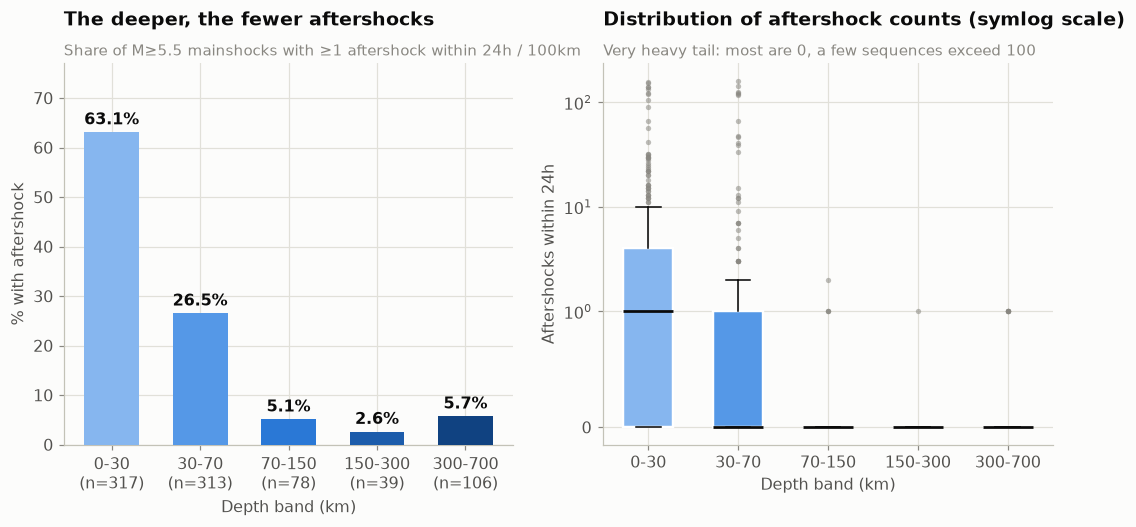

In [13]:
# Figure 1: aftershock productivity by depth band (main RQ1 result)
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.5))
labels = prod.index.astype(str).tolist()
colors = SEQ5[:len(labels)]

ax = axes[0]
tick_lab = [f"{l}\n(n={nn})" for l, nn in zip(labels, prod["n_sequences"])]
bars = ax.bar(tick_lab, prod["pct_with_aftershock"], color=colors, width=0.62, zorder=3)
for bar, v in zip(bars, prod["pct_with_aftershock"]):
    ax.text(bar.get_x()+bar.get_width()/2, v+1.6, f"{v:.1f}%", ha="center",
            fontsize=10.5, color=PAL["ink"], fontweight="semibold")
finish(ax, "The deeper, the fewer aftershocks",
       f"Share of M≥{MS_MIN} mainshocks with ≥1 aftershock within {WIN_H}h / {WIN_KM}km",
       "Depth band (km)", "% with aftershock")
ax.set_ylim(0, max(prod["pct_with_aftershock"])*1.22)

ax = axes[1]
data = [ms.loc[ms["depth_bin"]==b, "n_after24h"].values for b in prod.index]
bp = ax.boxplot(data, tick_labels=labels, patch_artist=True, widths=0.55,
                medianprops=dict(color=PAL["ink"], lw=1.8),
                flierprops=dict(marker="o", ms=3.5, mfc=PAL["muted"],
                                mec="none", alpha=0.55))
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c); patch.set_edgecolor("white"); patch.set_linewidth(1.6)
ax.set_yscale("symlog", linthresh=1)
finish(ax, "Distribution of aftershock counts (symlog scale)",
       "Very heavy tail: most are 0, a few sequences exceed 100",
       "Depth band (km)", "Aftershocks within 24h")
save(fig, "fig_rq1_productivity_by_depth.png"); plt.show()

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


saved figure: report\fig_rq1_map_epicenters.png


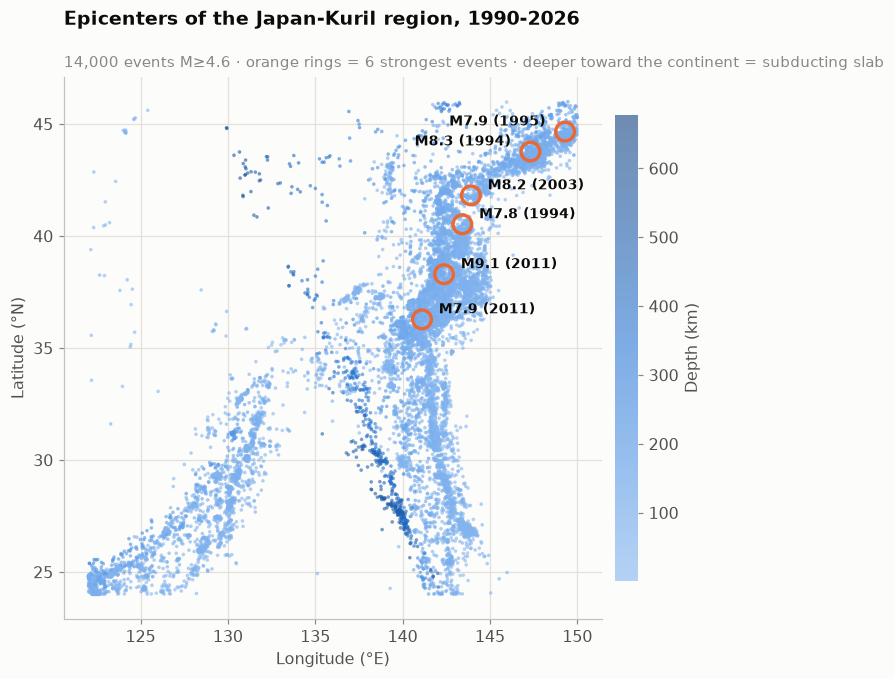

In [14]:
# Figure 2: spatial distribution
fig, ax = plt.subplots(figsize=(7.6, 6.4))
d = cat.sample(min(len(cat), 14000), random_state=0)
sc = ax.scatter(d["longitude"], d["latitude"], c=d["depth"], s=5.5, alpha=0.6,
                cmap=matplotlib.colors.LinearSegmentedColormap.from_list("blues", SEQ5),
                linewidths=0, zorder=3)
big = cat.nlargest(6, "mag")
ax.scatter(big["longitude"], big["latitude"], s=150, facecolor="none",
           edgecolor=PAL["s2"], linewidth=2.2, zorder=5)
for _, r in big.iterrows():
    # points near the right edge -> put the label on the left so it does not hit the colorbar
    right_edge = r["longitude"] > 145.5
    ax.annotate(f"M{r['mag']:.1f} ({r['time']:%Y})", (r["longitude"], r["latitude"]),
                textcoords="offset points",
                xytext=(-13, 4) if right_edge else (11, 4),
                ha="right" if right_edge else "left",
                fontsize=9, color=PAL["ink"], fontweight="semibold", zorder=6)
cb = fig.colorbar(sc, ax=ax, pad=0.02, shrink=0.86)
cb.set_label("Depth (km)", color=PAL["ink2"]); cb.outline.set_visible(False)
finish(ax, "Epicenters of the Japan-Kuril region, 1990-2026",
       f"{len(d):,} events M≥{Mc} · orange rings = 6 strongest events · deeper toward the continent = subducting slab",
       "Longitude (°E)", "Latitude (°N)")
save(fig, "fig_rq1_map_epicenters.png"); plt.show()

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


saved figure: report\fig_rq1_events_per_year.png


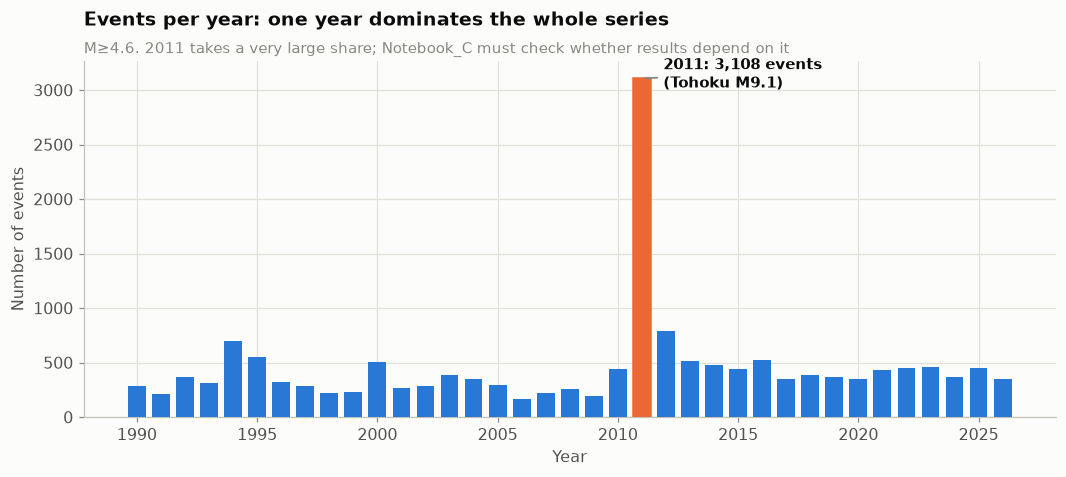

2011 accounts for 18.6% of all events (3,108/16,687)


In [15]:
# Figure 3: yearly time series
by_year = cat.groupby(cat["time"].dt.year).agg(
    n_events=("id","size"), max_mag=("mag","max")).reset_index(names="year")
fig, ax = plt.subplots(figsize=(11.4, 4.2))
bars = ax.bar(by_year["year"], by_year["n_events"], color=PAL["s1"], width=0.74, zorder=3)
top = by_year.nlargest(1, "n_events").iloc[0]
bars[list(by_year["year"]).index(top["year"])].set_color(PAL["s2"])
ax.annotate(f"{int(top['year'])}: {int(top['n_events']):,} events\n(Tohoku M9.1)",
            xy=(top["year"], top["n_events"]), xytext=(14, -6),
            textcoords="offset points", fontsize=10, color=PAL["ink"],
            fontweight="semibold",
            arrowprops=dict(arrowstyle="-", color=PAL["muted"], lw=1.2))
finish(ax, "Events per year: one year dominates the whole series",
       f"M≥{Mc}. 2011 takes a very large share; Notebook_C must check whether results depend on it",
       "Year", "Number of events")
save(fig, "fig_rq1_events_per_year.png"); plt.show()
print(f"2011 accounts for {top['n_events']/by_year['n_events'].sum()*100:.1f}% of all events "
      f"({int(top['n_events']):,}/{by_year['n_events'].sum():,})")

saved figure: report\fig_rq1_magnitude_vs_aftershocks.png


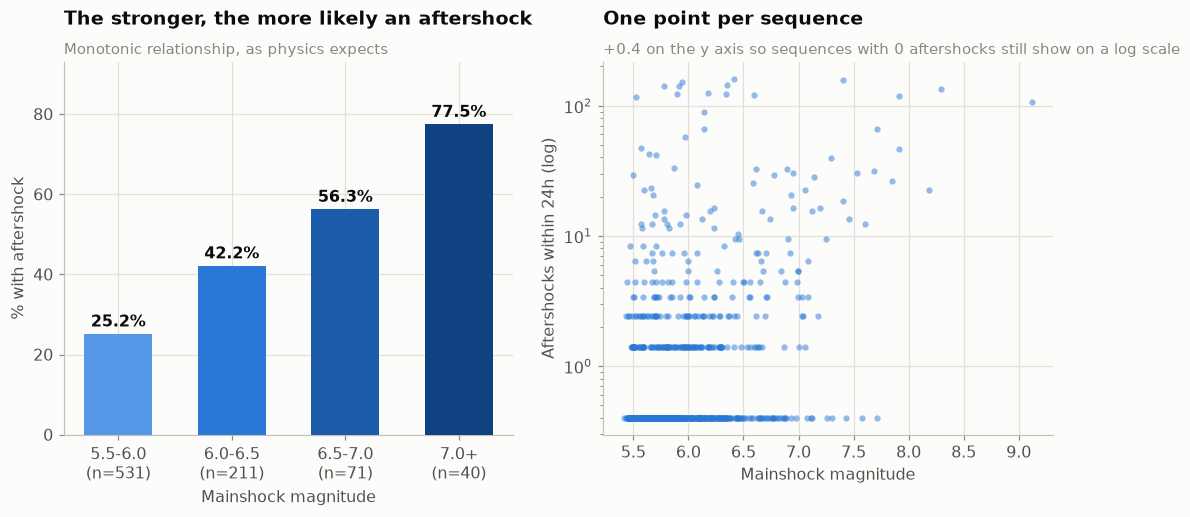

In [16]:
# Figure 4: magnitude vs aftershock count
ms["mag_bin"] = pd.cut(ms["mag"], [5.5, 6.0, 6.5, 7.0, 9.5],
                       labels=["5.5-6.0","6.0-6.5","6.5-7.0","7.0+"], right=False)
g2 = ms.groupby("mag_bin", observed=True).agg(
    n=("any_after","size"), pct=("any_after","mean"), mean=("n_after24h","mean"))
g2["pct"] = (g2["pct"]*100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.4))
ax = axes[0]
tick2 = [f"{l}\n(n={nn})" for l, nn in zip(g2.index.astype(str), g2["n"])]
bars = ax.bar(tick2, g2["pct"], color=SEQ5[1:5], width=0.6, zorder=3)
for bar, v in zip(bars, g2["pct"]):
    ax.text(bar.get_x()+bar.get_width()/2, v+1.8, f"{v:.1f}%", ha="center",
            fontsize=10.5, color=PAL["ink"], fontweight="semibold")
finish(ax, "The stronger, the more likely an aftershock", "Monotonic relationship, as physics expects",
       "Mainshock magnitude", "% with aftershock")
ax.set_ylim(0, max(g2["pct"])*1.2)

ax = axes[1]
jit = np.random.default_rng(0).normal(0, 0.035, len(ms))
ax.scatter(ms["mag"]+jit, ms["n_after24h"]+0.4, s=17, alpha=0.5,
           color=PAL["s1"], linewidths=0, zorder=3)
ax.set_yscale("log")
finish(ax, "One point per sequence", "+0.4 on the y axis so sequences with 0 aftershocks still show on a log scale",
       "Mainshock magnitude", "Aftershocks within 24h (log)")
save(fig, "fig_rq1_magnitude_vs_aftershocks.png"); plt.show()

## Notebook_A test cases (run before the handoff)

Seven checks. If there is an `AssertionError`, **do not hand off** to Notebook_B.

In [17]:
# Notebook_A test cases
def t(name, cond, detail=""):
    assert cond, f"FAIL: {name} {detail}"
    print(f"  PASS  {name}")

print("Notebook_A test cases")
t("1. no duplicate ids in the catalog", cat["id"].is_unique)
t("2. the label is not among the features",
  "n_after24h" not in ("mag","depth","latitude","longitude"))
t("3. the label varies (not degenerate)",
  0.05 < ms["any_after"].mean() < 0.95, f"positive rate = {ms['any_after'].mean():.3f}")
t("4. enough independent groups", len(ms) >= 300, f"only {len(ms)} sequences")
t("5. source 2 match rate above 80%", len(link)/len(nc) >= 0.80,
  f"only matched {len(link)/len(nc)*100:.1f}%")
t("6. every feature is known at time t",
  all(c in cat.columns for c in ("mag","depth","latitude","longitude")))

# leakage check: no feature may be (almost) identical to the label
corr = ms[["mag","depth","n_after24h"]].corr(method="spearman")["n_after24h"]
print("\nSpearman correlation with the label (no column may be ~1.0):")
print(corr.round(3).to_string())
t("7. no feature duplicates the label", (corr.drop("n_after24h").abs() < 0.95).all())

Notebook_A test cases
  PASS  1. no duplicate ids in the catalog
  PASS  2. the label is not among the features
  PASS  3. the label varies (not degenerate)
  PASS  4. enough independent groups
  PASS  5. source 2 match rate above 80%
  PASS  6. every feature is known at time t

Spearman correlation with the label (no column may be ~1.0):
mag           0.276
depth        -0.492
n_after24h    1.000
  PASS  7. no feature duplicates the label


In [18]:
# Handoff to Notebook_B
OUT_COLS = ["id","time","year","latitude","longitude","depth","mag","magType","place",
            "depth_bin","n_after24h","any_after"]
ms[OUT_COLS].to_parquet(PROC / "mainshocks.parquet", index=False)
cat[["id","time","latitude","longitude","depth","mag","is_aftershock"]].to_parquet(
    PROC / "catalog_declustered.parquet", index=False)
link.to_parquet(PROC / "source_link.parquet", index=False)

def sha(p):
    return hashlib.sha256(open(p, "rb").read()).hexdigest()[:16]

manifest = {
    "topic": "Short-term aftershock forecasting, Japan-Kuril region",
    "source_1": {"agency":"USGS","dataset":"ANSS ComCat (FDSN Event Web Service)",
                 "n_events_raw": int(len(usgs)), "n_events_clean": int(len(h))},
    "source_2": {"agency":"NOAA/NCEI",
                 "significant_earthquakes": int(len(ncei_eq)),
                 "tsunami_events": int(len(ncei_tsu)),
                 "tsunami_runups": int(len(ncei_run)),
                 "usgs_match_rate": round(len(link)/len(nc), 4)},
    "bbox": {"lat":[24,46], "lon":[122,150], "region_name":"Japan-Kuril"},
    "Mc": float(Mc), "b_value": round(float(-b_gr), 3),
    "declustering": "Gardner-Knopoff 1974",
    "frac_aftershocks": round(float(cat["is_aftershock"].mean()), 4),
    "mainshock_min_mag": float(MS_MIN),
    "label_window": {"hours": WIN_H, "km": WIN_KM, "min_mag": float(Mc)},
    "n_sequences": int(len(ms)),
    "positive_rate": round(float(ms["any_after"].mean()), 4),
    "naive_accuracy": round(float(max(ms["any_after"].mean(), 1-ms["any_after"].mean())), 4),
    "handoff_columns": OUT_COLS,
    "dropped_columns": audit.loc[audit["decision"]=="DROP","column"].tolist(),
    "sha256_mainshocks": sha(PROC / "mainshocks.parquet"),
}
with open(PROC / "manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2)
print(json.dumps(manifest, ensure_ascii=False, indent=2))
print("\nHANDED OFF:", PROC / "mainshocks.parquet", "and", PROC / "manifest.json")

{
  "topic": "Short-term aftershock forecasting, Japan-Kuril region",
  "source_1": {
    "agency": "USGS",
    "dataset": "ANSS ComCat (FDSN Event Web Service)",
    "n_events_raw": 40931,
    "n_events_clean": 40924
  },
  "source_2": {
    "agency": "NOAA/NCEI",
    "significant_earthquakes": 429,
    "tsunami_events": 385,
    "tsunami_runups": 12939,
    "usgs_match_rate": 0.973
  },
  "bbox": {
    "lat": [
      24,
      46
    ],
    "lon": [
      122,
      150
    ],
    "region_name": "Japan-Kuril"
  },
  "Mc": 4.6,
  "b_value": 1.018,
  "declustering": "Gardner-Knopoff 1974",
  "frac_aftershocks": 0.6233,
  "mainshock_min_mag": 5.5,
  "label_window": {
    "hours": 24,
    "km": 100,
    "min_mag": 4.6
  },
  "n_sequences": 853,
  "positive_rate": 0.3447,
  "naive_accuracy": 0.6553,
  "handoff_columns": [
    "id",
    "time",
    "year",
    "latitude",
    "longitude",
    "depth",
    "mag",
    "magType",
    "place",
    "depth_bin",
    "n_after24h",
    "any_after"

## Common errors and fixes (read when you see red text)

| Red text | Cause | Fix |
|---|---|---|
| `AssertionError: Missing files in data/raw_japan` | data not downloaded yet | run `python scripts/fetch_japan_quake_data.py` |
| `ValueError: time data ... doesn't match format` | pandas guessed the ISO format wrong | already handled with `format="ISO8601"`; if it still fails, add `errors="coerce"` and then `dropna` |
| `ModuleNotFoundError: duckdb` | missing library | `pip install duckdb pyarrow` |
| `Binder Error: ... WINDOW` | DuckDB too old, no `WINDOW ... AS` support | `pip install -U duckdb` (needs ≥ 0.9) |
| Q3 returns `n_events_prev_24h` all 0 | used `ROWS` instead of `RANGE` | it must be `RANGE BETWEEN INTERVAL '24' HOURS PRECEDING` |
| `AssertionError: enough independent groups` | `MS_MIN` set too high | lower `MS_MIN` to 5.0 and state it in the report |
| Figure labels show boxes instead of characters | the font is missing glyphs | `plt.rcParams["font.family"]="DejaVu Sans"` |

## Checklist before reporting (tick [x] when the evidence file exists)

- [ ] `data/processed/mainshocks.parquet` and `manifest.json` created, and Notebook_B can load them
- [ ] `sql/queries.sql` has all 9 queries and **re-runs** in DuckDB
- [ ] `report/table_col_audit.csv`: states which columns were dropped and **why**
- [ ] `report/table_cleaning_log.csv`: rows lost at each step
- [ ] `report/table_source_link.csv`: match rate between the two sources
- [ ] `report/table_rq1_tests.csv`: chi-square, Kruskal-Wallis, Spearman with p-values
- [ ] `report/table_rq1_productivity.csv`: productivity by depth table
- [ ] The 5 `fig_rq1_*.png` figures are readable, no overflowing text, labels render correctly
- [ ] All 7 test cases PASS
- [ ] `docs/AI_Audit_Log_A.md` has a line for every prompt that changed the work
- [ ] The report **states** three limitations: (1) the region includes Russia's Kurils, (2) USGS is not Japan's primary agency so Mc is high, (3) 2011 dominates

## Progress report template (slot 3, Tuesdays and Fridays, 7:00 to 9:15)

**Student A: Notebook_A, week …**

1. **Done:** loaded 2 sources (USGS … events / NOAA/NCEI … events), cleaned down to … rows, Mc = …, declustered into … independent sequences, 9 SQL queries, 5 RQ1 figures.
2. **Key numbers:** share of mainshocks with an aftershock within 24h = … %; shallow (<70 km) … % vs deep (≥70 km) … %, chi-square p = …
3. **Source 2 match:** … / … = … %, median time offset … s.
4. **Blockers:** …
5. **Next week:** hand `mainshocks.parquet` to B; B runs Steps 4 and 6a.
6. **Limitations written into the report:** …